# Scube1 and Cell Marker Expression in Dorsal Striatum (10x snRNA-seq)

This notebook examines Scube1 expression alongside canonical cell-type markers
in the dorsal striatum (caudate-putamen) using 10x snRNA-seq from the Allen
Brain Cell Atlas.

### Gene Panel (12 genes)
- **Scube1**: Signal peptide, CUB and EGF-like domain-containing protein 1
- **MSN markers**: Drd1 (D1-MSN), Drd2 (D2-MSN), Adora2a (indirect pathway), Ppp1r1b (DARPP-32, pan-MSN)
- **Interneuron markers**: Chat (cholinergic), Sst (somatostatin), Pvalb (parvalbumin)
- **Neurotransmitter markers**: Gad1, Gad2 (GABAergic), Slc17a7 (glutamatergic), Th (catecholaminergic)

In [1]:
import pandas as pd
import numpy as np
import re
import os
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Load Pre-extracted Expression Data

In [2]:
csv_expr = 'strd_scube1_expression.csv'
csv_meta = 'strd_scube1_metadata.csv'

if not os.path.exists(csv_expr):
    raise FileNotFoundError(
        f'{csv_expr} not found. Run extract_strd_scube1_expression.py first.'
    )

expression_data = pd.read_csv(csv_expr, index_col=0)
metadata = pd.read_csv(csv_meta, index_col=0)
print(f'Expression: {expression_data.shape[0]:,} cells x {expression_data.shape[1]} genes')
print(f'Metadata: {metadata.shape[0]:,} cells')

Expression: 55,626 cells x 12 genes
Metadata: 55,626 cells


In [3]:
# Gene groupings for dot plot
target_genes = list(expression_data.columns)
print(f'Genes: {target_genes}')

gene_groups = {
    'Gene of interest': ['Scube1'],
    'MSN markers': ['Drd1', 'Drd2', 'Adora2a', 'Ppp1r1b'],
    'Interneuron': ['Chat', 'Sst', 'Pvalb'],
    'NT markers': ['Gad1', 'Gad2', 'Slc17a7', 'Th'],
}
gene_groups = {k: [g for g in v if g in target_genes] for k, v in gene_groups.items()}
gene_groups = {k: v for k, v in gene_groups.items() if v}

Genes: ['Scube1', 'Drd1', 'Drd2', 'Adora2a', 'Ppp1r1b', 'Chat', 'Sst', 'Pvalb', 'Gad1', 'Gad2', 'Slc17a7', 'Th']


## 2. Overview of Dorsal Striatum Cell Types

In [4]:
meta = metadata.loc[expression_data.index].copy()
meta['subclass_short'] = meta['subclass'].apply(
    lambda x: re.sub(r'^\d+\s+', '', str(x))
)
meta['supertype_short'] = meta['supertype'].apply(
    lambda x: re.sub(r'^\d+\s+', '', str(x))
)
meta['class_short'] = meta['class'].apply(
    lambda x: re.sub(r'^\d+\s+', '', str(x))
)

print(f'Dorsal striatum cells: {len(meta):,}')
print(f'\nBy subclass (>= 20 cells):')
sc_counts = meta.groupby('subclass_short', observed=True).size().sort_values(ascending=False)
for sc_name, cnt in sc_counts.items():
    if cnt >= 20:
        nt = meta[meta['subclass_short'] == sc_name]['neurotransmitter'].mode()
        nt_str = nt.iloc[0] if len(nt) > 0 else ''
        print(f'  {sc_name}: {cnt:,} ({nt_str})')

Dorsal striatum cells: 55,626

By subclass (>= 20 cells):


  STR D2 Gaba: 18,139 (GABA)
  STR D1 Gaba: 16,660 (GABA)
  Astro-TE NN: 6,190 ()
  Oligo NN: 3,633 ()
  Microglia NN: 2,277 ()


  Endo NN: 1,811 ()
  OB-STR-CTX Inh IMN: 1,642 (GABA)
  OPC NN: 1,331 ()
  STR D1 Sema5a Gaba: 780 (GABA)
  Peri NN: 556 ()
  STR-PAL Chst9 Gaba: 437 (GABA)
  STR Prox1 Lhx6 Gaba: 367 (GABA)
  SMC NN: 284 ()
  Sst Chodl Gaba: 230 (GABA)
  STR Lhx8 Gaba: 178 (GABA)
  L6 CT CTX Glut: 172 (Glut)
  VLMC NN: 148 ()
  L6 IT CTX Glut: 116 (Glut)
  Astro-NT NN: 111 ()
  BAM NN: 110 ()
  OB-in Frmd7 Gaba: 77 (GABA)
  LA-BLA-BMA-PA Glut: 76 (Glut)
  Ependymal NN: 59 ()
  IT EP-CLA Glut: 37 (Glut)
  PAL-STR Gaba-Chol: 30 (Chol)
  OB-out Frmd7 Gaba: 30 (GABA)


## 3. Dot Plot: Scube1 + Markers by Subclass

Focus on neuronal subclasses with >= 20 cells.

Subclasses with >= 20 cells: 26
AnnData: 55,481 cells x 12 genes, 26 subclasses


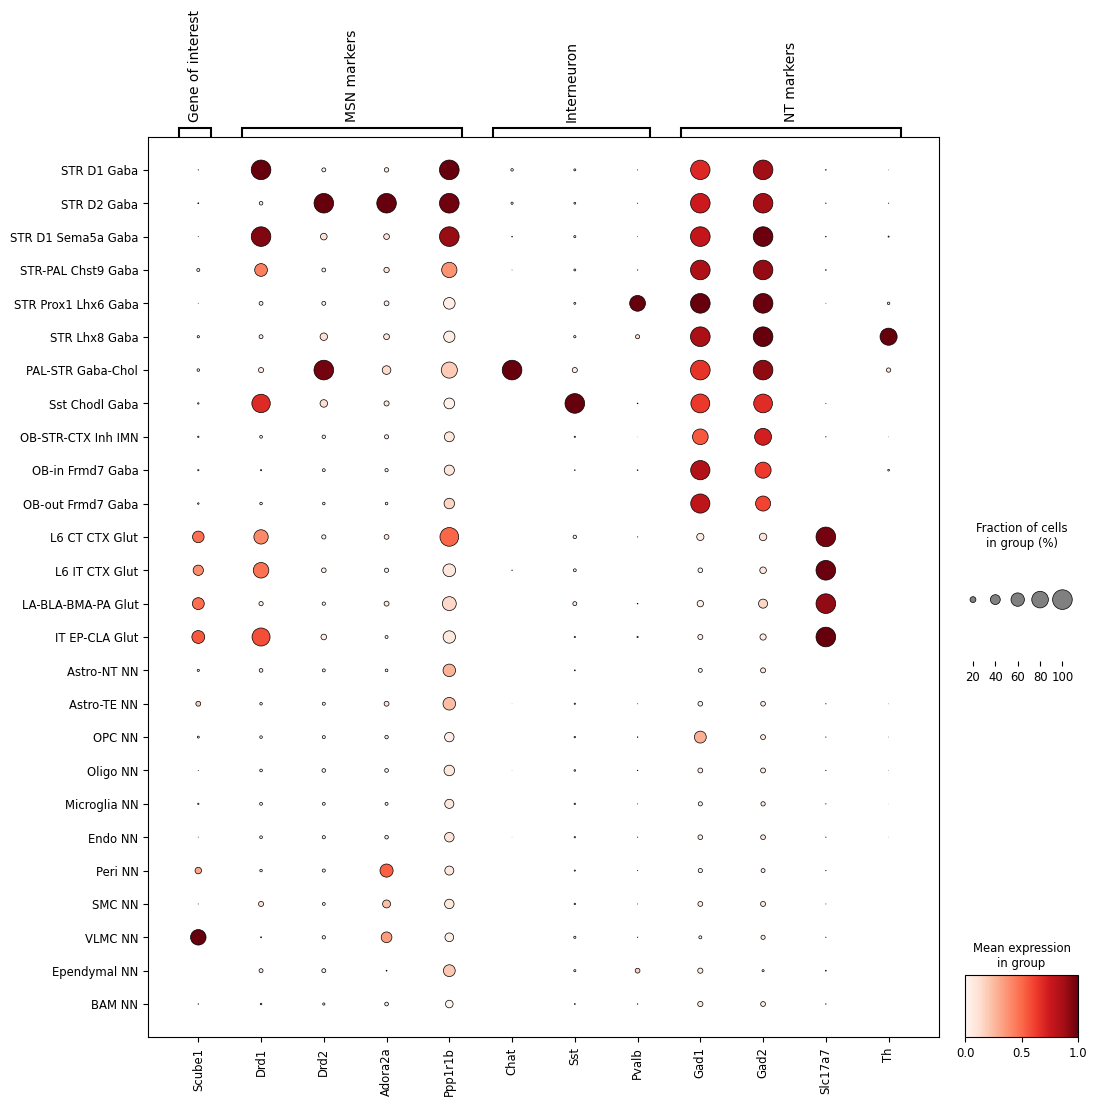

Saved: dotplot_STRd_Scube1_by_subclass.png


In [5]:
# Filter to subclasses with >= 20 cells
valid_sc = sc_counts[sc_counts >= 20].index.tolist()
print(f'Subclasses with >= 20 cells: {len(valid_sc)}')

# Build AnnData
mask = meta['subclass_short'].isin(valid_sc)
adata = anndata.AnnData(
    X=expression_data.loc[mask].values,
    obs=meta.loc[mask][['subclass_short', 'supertype_short', 'class_short', 'neurotransmitter']].copy(),
    var=pd.DataFrame(index=target_genes)
)

# Sort subclasses: MSNs first, then interneurons, then glia
def subclass_sort_key(name):
    if 'STR D1 Gaba' == name: return (0, name)
    elif 'STR D2 Gaba' == name: return (1, name)
    elif 'STR D1 Sema5a' in name: return (2, name)
    elif 'STR-PAL' in name: return (3, name)
    elif 'STR Prox1' in name: return (4, name)
    elif 'STR Lhx8' in name: return (5, name)
    elif 'PAL-STR' in name: return (6, name)
    elif 'Sst Chodl' in name: return (7, name)
    elif 'OB-STR' in name: return (8, name)
    elif 'OB-in' in name: return (9, name)
    elif 'OB-out' in name: return (10, name)
    elif 'OB' in name: return (11, name)
    elif 'Lamp5' in name: return (12, name)
    elif 'CEA' in name: return (13, name)
    elif 'CNU' in name: return (14, name)
    elif 'L6 CT' in name: return (15, name)
    elif 'L6 IT' in name: return (16, name)
    elif 'LA-BLA' in name: return (17, name)
    elif 'IT EP' in name: return (18, name)
    elif 'Glut' in name: return (19, name)
    elif 'Astro' in name: return (20, name)
    elif 'OPC' in name: return (21, name)
    elif 'Oligo' in name: return (22, name)
    elif 'Micro' in name: return (23, name)
    elif 'Endo' in name: return (24, name)
    elif 'Peri' in name: return (25, name)
    elif 'SMC' in name: return (26, name)
    elif 'VLMC' in name: return (27, name)
    elif 'Ependymal' in name: return (28, name)
    elif 'BAM' in name: return (29, name)
    else: return (30, name)

sorted_sc = sorted(valid_sc, key=subclass_sort_key)
adata.obs['subclass_short'] = pd.Categorical(
    adata.obs['subclass_short'], categories=sorted_sc, ordered=True
)

n_sc = len(sorted_sc)
print(f'AnnData: {adata.shape[0]:,} cells x {adata.shape[1]} genes, {n_sc} subclasses')

dp = sc.pl.dotplot(
    adata,
    var_names=gene_groups,
    groupby='subclass_short',
    standard_scale='var',
    cmap='Reds',
    figsize=(12, max(5, n_sc * 0.45)),
    show=False,
    return_fig=True
)
dp.style(dot_edge_color='black', dot_edge_lw=0.5)
dp.savefig('dotplot_STRd_Scube1_by_subclass.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dotplot_STRd_Scube1_by_subclass.png')

## 4. Dot Plot: Neuronal Subclasses Only

Focused view on neurons, excluding glia and vascular cells.

Neuronal subclasses: 15


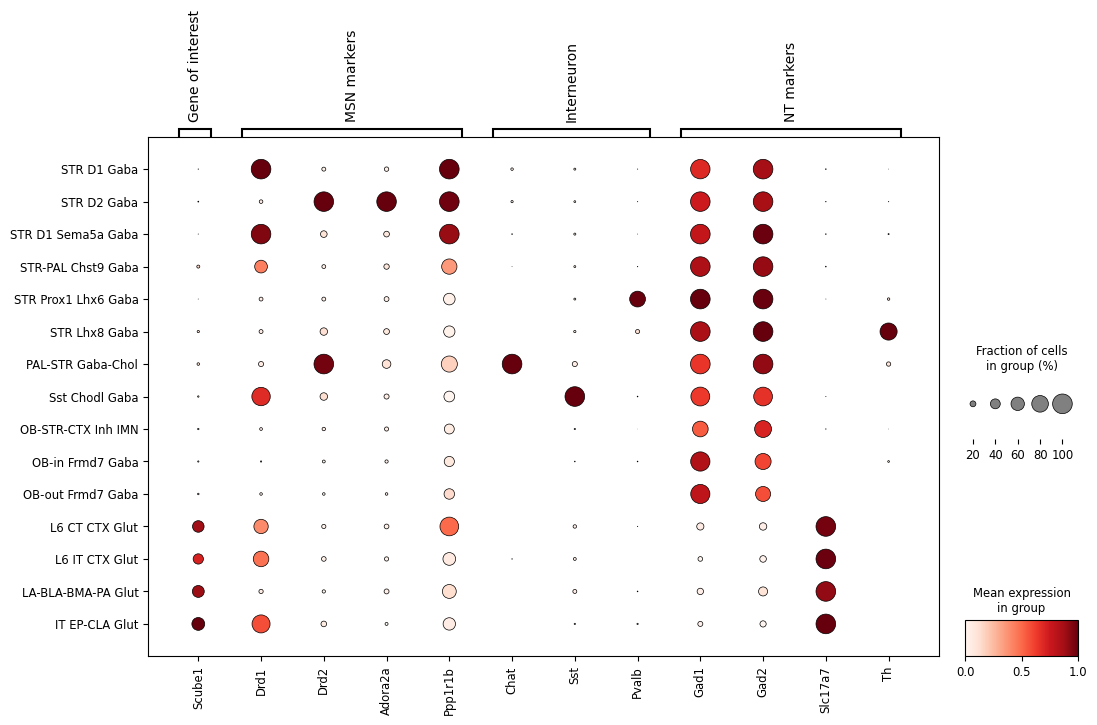

Saved: dotplot_STRd_Scube1_neurons.png


In [6]:
# Filter to neuronal subclasses
non_neuronal = {'Astro-TE NN', 'Astro-NT NN', 'OPC NN', 'Oligo NN',
                'Microglia NN', 'Endo NN', 'Peri NN', 'SMC NN',
                'VLMC NN', 'Ependymal NN', 'BAM NN'}
neuronal_sc = [s for s in sorted_sc if s not in non_neuronal]
print(f'Neuronal subclasses: {len(neuronal_sc)}')

adata_neuron = adata[adata.obs['subclass_short'].isin(neuronal_sc)].copy()
adata_neuron.obs['subclass_short'] = pd.Categorical(
    adata_neuron.obs['subclass_short'], categories=neuronal_sc, ordered=True
)

n_neuron = len(neuronal_sc)
dp2 = sc.pl.dotplot(
    adata_neuron,
    var_names=gene_groups,
    groupby='subclass_short',
    standard_scale='var',
    cmap='Reds',
    figsize=(12, max(5, n_neuron * 0.45)),
    show=False,
    return_fig=True
)
dp2.style(dot_edge_color='black', dot_edge_lw=0.5)
dp2.savefig('dotplot_STRd_Scube1_neurons.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dotplot_STRd_Scube1_neurons.png')

## 5. Heatmap: Mean Expression and Fraction Expressing

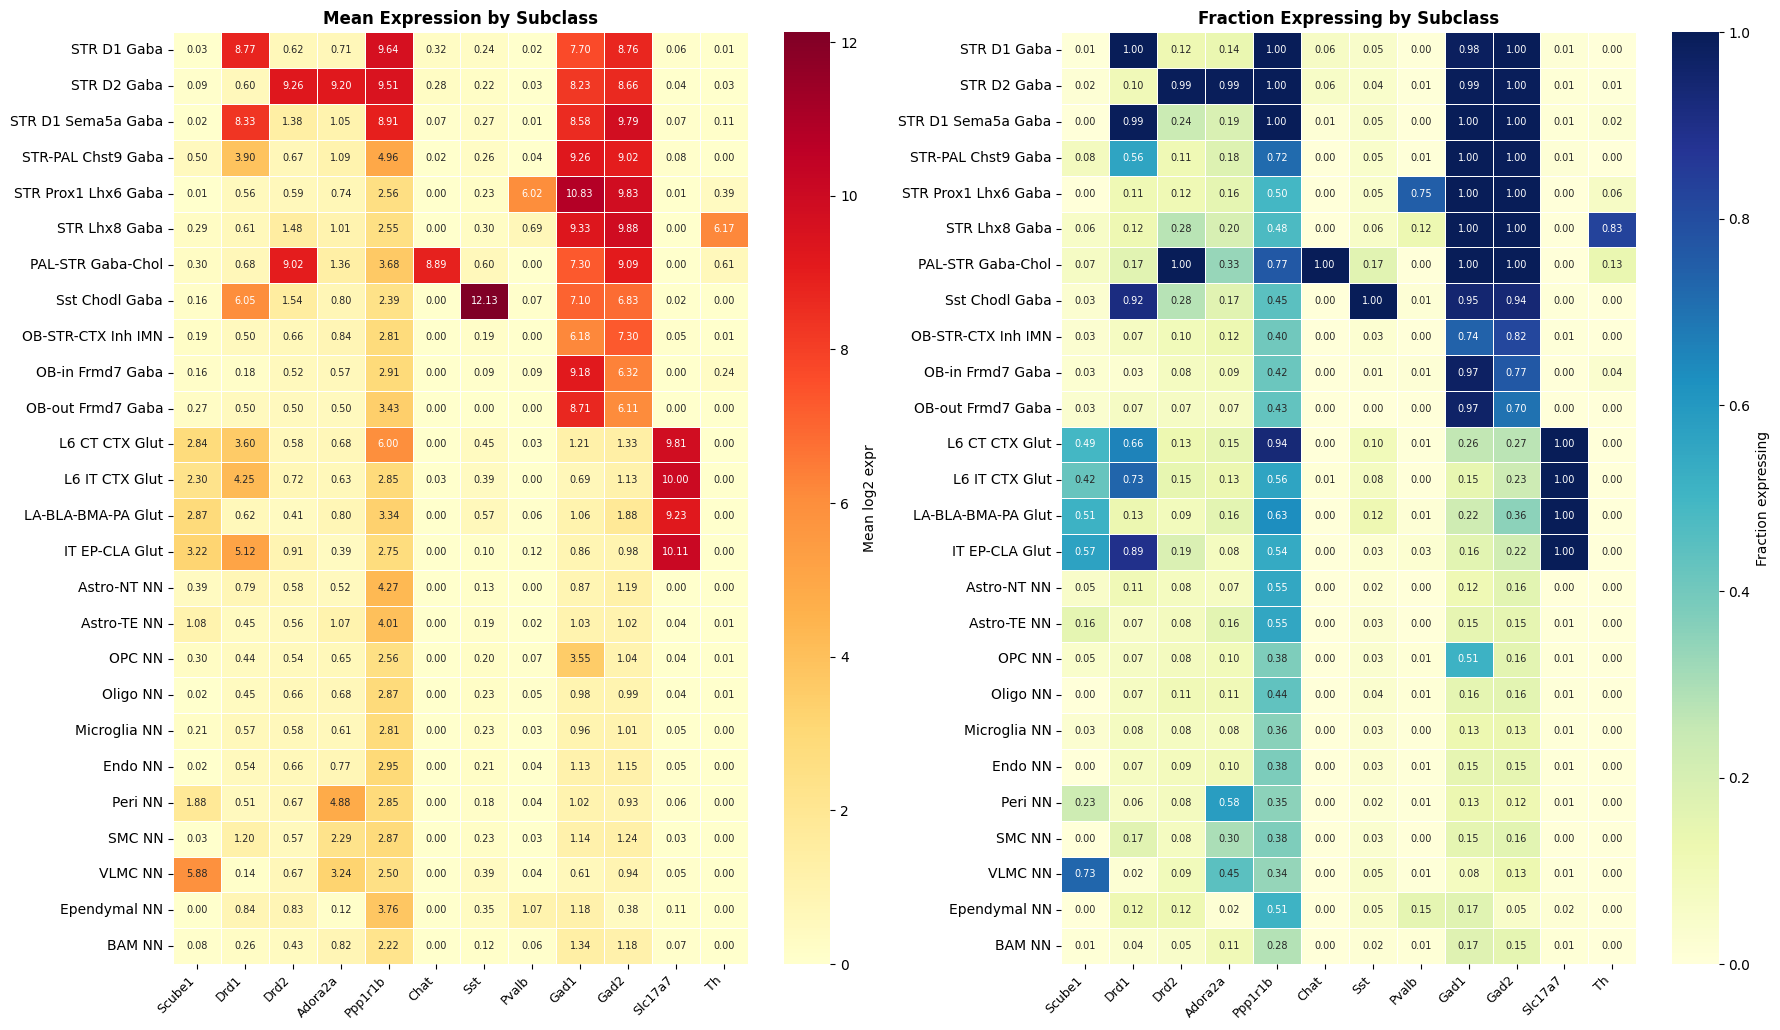

Saved: heatmap_STRd_Scube1_by_subclass.png


In [7]:
# Mean expression and fraction by subclass
expr_df = pd.DataFrame(adata.X, index=adata.obs.index, columns=target_genes)
expr_df['subclass'] = adata.obs['subclass_short'].values

sc_mean = expr_df.groupby('subclass', observed=True)[target_genes].mean().loc[sorted_sc]
sc_frac = expr_df.groupby('subclass', observed=True)[target_genes].apply(
    lambda x: (x > 0).mean()
).loc[sorted_sc]

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, n_sc * 0.4)))

sns.heatmap(sc_mean, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Mean log2 expr'},
            annot_kws={'size': 7})
axes[0].set_title('Mean Expression by Subclass', fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)

sns.heatmap(sc_frac, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Fraction expressing'},
            annot_kws={'size': 7})
axes[1].set_title('Fraction Expressing by Subclass', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('heatmap_STRd_Scube1_by_subclass.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_STRd_Scube1_by_subclass.png')

## 6. Enrichment: Scube1 Across Cell Types

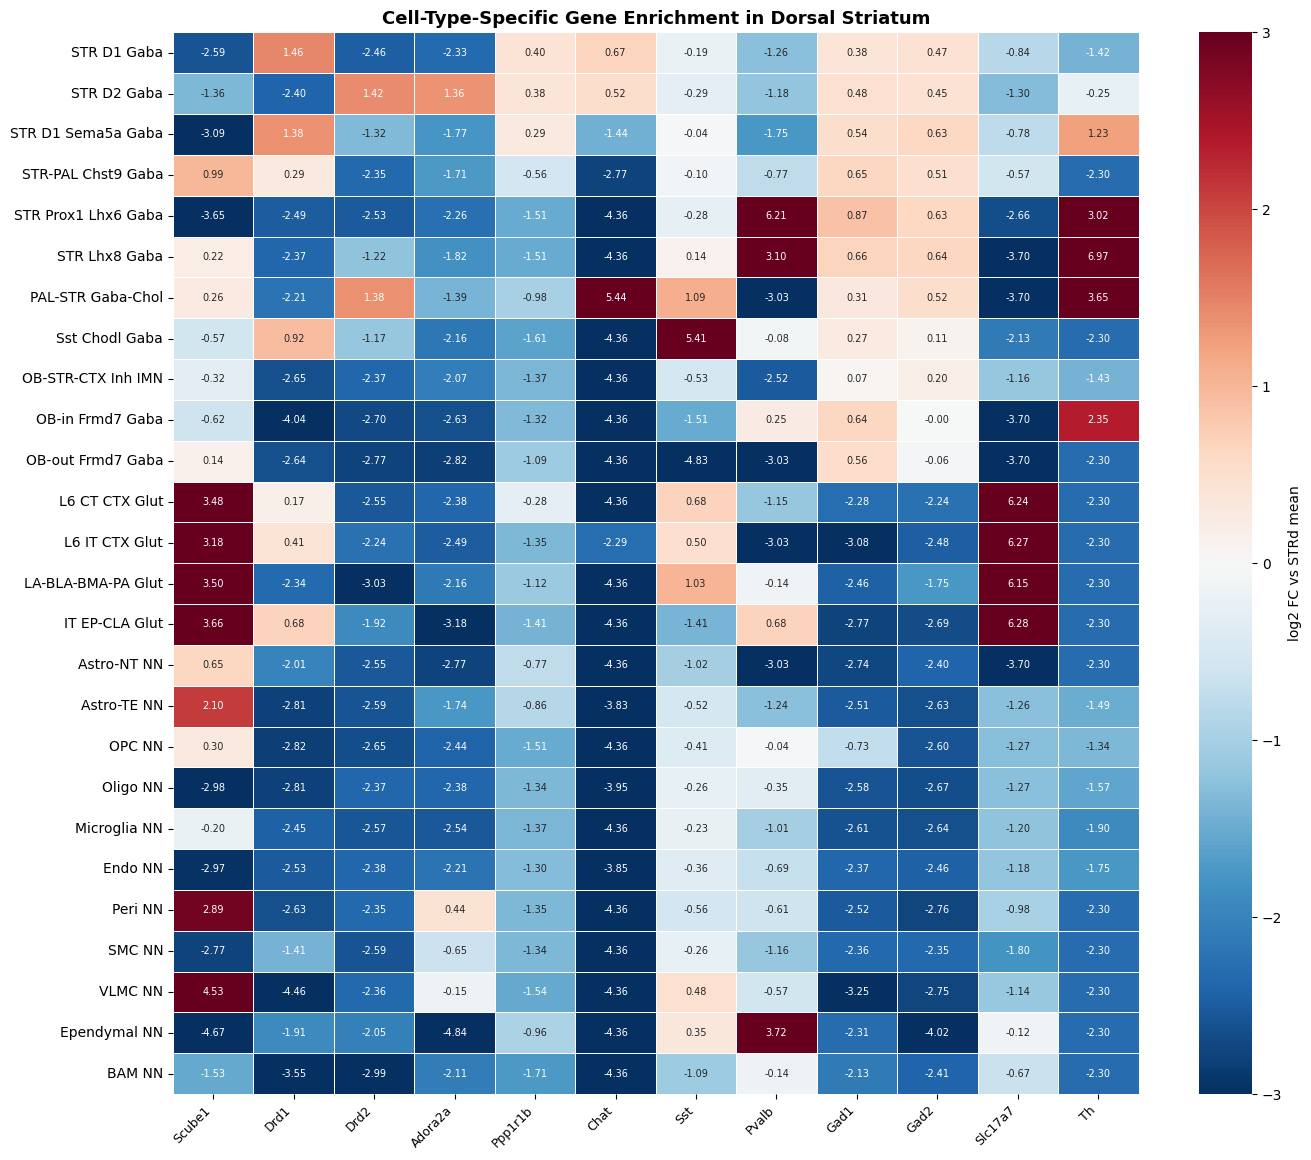

Saved: heatmap_STRd_Scube1_enrichment.png


In [8]:
# Log2 fold-change vs overall STRd mean
overall_mean = expr_df[target_genes].mean()
pseudocount = 0.01
log2fc = np.log2((sc_mean + pseudocount) / (overall_mean + pseudocount))

fig, ax = plt.subplots(figsize=(14, max(5, n_sc * 0.45)))
sns.heatmap(log2fc, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-3, vmax=3,
            cbar_kws={'label': 'log2 FC vs STRd mean'},
            annot_kws={'size': 7})
ax.set_title('Cell-Type-Specific Gene Enrichment in Dorsal Striatum',
             fontweight='bold', fontsize=13)
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_STRd_Scube1_enrichment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_STRd_Scube1_enrichment.png')

## 7. Scube1 Expression: D1 vs D2 MSNs

Compare Scube1 expression between direct (D1) and indirect (D2) pathway MSNs.

D1 MSNs: 16,660 cells
  Scube1 mean: 0.032
  Scube1 fraction expressing: 0.006
D2 MSNs: 18,139 cells
  Scube1 mean: 0.090
  Scube1 fraction expressing: 0.017


/tmp/ipykernel_9694/1390513868.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_violin, x='MSN type', y='Scube1 (log2)',


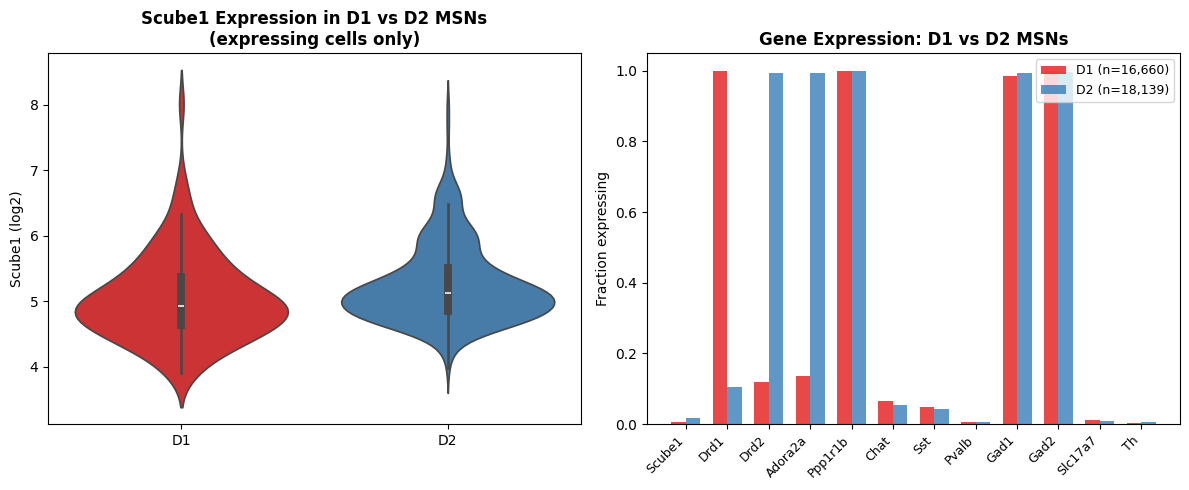

Saved: barplot_STRd_D1_vs_D2.png


In [9]:
# D1 vs D2 comparison
d1_mask = meta['subclass_short'] == 'STR D1 Gaba'
d2_mask = meta['subclass_short'] == 'STR D2 Gaba'

d1_scube1 = expression_data.loc[d1_mask, 'Scube1']
d2_scube1 = expression_data.loc[d2_mask, 'Scube1']

print(f'D1 MSNs: {len(d1_scube1):,} cells')
print(f'  Scube1 mean: {d1_scube1.mean():.3f}')
print(f'  Scube1 fraction expressing: {(d1_scube1 > 0).mean():.3f}')
print(f'D2 MSNs: {len(d2_scube1):,} cells')
print(f'  Scube1 mean: {d2_scube1.mean():.3f}')
print(f'  Scube1 fraction expressing: {(d2_scube1 > 0).mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Violin plot
d1_vals = d1_scube1[d1_scube1 > 0]
d2_vals = d2_scube1[d2_scube1 > 0]
data_violin = pd.DataFrame({
    'Scube1 (log2)': pd.concat([d1_vals, d2_vals]),
    'MSN type': ['D1'] * len(d1_vals) + ['D2'] * len(d2_vals)
})

ax = axes[0]
sns.violinplot(data=data_violin, x='MSN type', y='Scube1 (log2)',
               palette={'D1': '#e41a1c', 'D2': '#377eb8'}, ax=ax, inner='box')
ax.set_title('Scube1 Expression in D1 vs D2 MSNs\n(expressing cells only)',
             fontweight='bold')
ax.set_xlabel('')

# Bar chart: fraction expressing for all genes
ax = axes[1]
d1_frac = (expression_data.loc[d1_mask] > 0).mean()
d2_frac = (expression_data.loc[d2_mask] > 0).mean()
x = np.arange(len(target_genes))
width = 0.35
ax.bar(x - width/2, d1_frac, width, label=f'D1 (n={d1_mask.sum():,})',
       color='#e41a1c', alpha=0.8)
ax.bar(x + width/2, d2_frac, width, label=f'D2 (n={d2_mask.sum():,})',
       color='#377eb8', alpha=0.8)
ax.set_ylabel('Fraction expressing')
ax.set_title('Gene Expression: D1 vs D2 MSNs', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_genes, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('barplot_STRd_D1_vs_D2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: barplot_STRd_D1_vs_D2.png')

## 8. Summary Statistics

In [10]:
print('=' * 80)
print('Mean Expression (log2) — Dorsal Striatum by Subclass (10x snRNA-seq)')
print('=' * 80)
display(sc_mean.round(3))

print('\n' + '=' * 80)
print('Fraction Expressing — Dorsal Striatum by Subclass (10x snRNA-seq)')
print('=' * 80)
display(sc_frac.round(3))

# Save CSVs
sc_mean.to_csv('strd_scube1_subclass_mean_expression.csv')
sc_frac.to_csv('strd_scube1_subclass_frac_expressing.csv')
log2fc.to_csv('strd_scube1_subclass_enrichment.csv')
print('\nSaved summary CSVs.')

# Scube1 summary
print(f'\nScube1 expression summary by subclass:')
scube1_summary = pd.DataFrame({
    'n_cells': sc_counts.loc[sorted_sc],
    'mean_expr': sc_mean['Scube1'],
    'frac_expr': sc_frac['Scube1'],
    'log2fc': log2fc['Scube1']
}).sort_values('frac_expr', ascending=False)
print(scube1_summary.round(3).to_string())

print(f'\n{"=" * 80}')
print(f'Total STRd cells: {len(expression_data):,}')
print(f'Subclasses (>= 20 cells): {n_sc}')
print(f'Genes: {len(target_genes)}')

Mean Expression (log2) — Dorsal Striatum by Subclass (10x snRNA-seq)


,Scube1,Drd1,Drd2,Adora2a,Ppp1r1b,Chat,Sst,Pvalb,Gad1,Gad2,Slc17a7,Th
subclass,,,,,,,,,,,,
STR D1 Gaba,0.032,8.770,0.619,0.706,9.639,0.317,0.239,0.024,7.698,8.763,0.063,0.008
STR D2 Gaba,0.090,0.595,9.261,9.196,9.508,0.284,0.223,0.026,8.228,8.659,0.043,0.031
STR D1 Sema5a Gaba,0.020,8.326,1.381,1.047,8.913,0.065,0.268,0.014,8.578,9.795,0.066,0.106
STR-PAL Chst9 Gaba,0.498,3.900,0.673,1.087,4.955,0.020,0.256,0.038,9.262,9.016,0.077,0.000
STR Prox1 Lhx6 Gaba,0.010,0.560,0.591,0.739,2.563,0.000,0.225,6.023,10.832,9.828,0.011,0.391
STR Lhx8 Gaba,0.287,0.609,1.483,1.007,2.550,0.000,0.303,0.688,9.329,9.875,0.000,6.167
PAL-STR Gaba-Chol,0.296,0.683,9.024,1.360,3.685,8.885,0.598,0.000,7.304,9.093,0.000,0.608
Sst Chodl Gaba,0.162,6.045,1.538,0.795,2.392,0.000,12.126,0.067,7.103,6.833,0.020,0.000
OB-STR-CTX Inh IMN,0.194,0.501,0.661,0.844,2.815,0.000,0.187,0.004,6.175,7.296,0.048,0.008



Fraction Expressing — Dorsal Striatum by Subclass (10x snRNA-seq)


,Scube1,Drd1,Drd2,Adora2a,Ppp1r1b,Chat,Sst,Pvalb,Gad1,Gad2,Slc17a7,Th
subclass,,,,,,,,,,,,
STR D1 Gaba,0.006,0.998,0.119,0.137,1.000,0.064,0.048,0.005,0.984,0.999,0.012,0.002
STR D2 Gaba,0.017,0.104,0.993,0.993,0.999,0.055,0.043,0.005,0.993,0.996,0.008,0.006
STR D1 Sema5a Gaba,0.004,0.995,0.236,0.194,0.999,0.013,0.050,0.003,0.999,1.000,0.012,0.022
STR-PAL Chst9 Gaba,0.082,0.561,0.114,0.178,0.716,0.002,0.046,0.007,0.998,0.995,0.014,0.000
STR Prox1 Lhx6 Gaba,0.003,0.114,0.117,0.155,0.496,0.000,0.046,0.747,1.000,1.000,0.003,0.063
STR Lhx8 Gaba,0.056,0.118,0.275,0.197,0.478,0.000,0.056,0.124,1.000,1.000,0.000,0.831
PAL-STR Gaba-Chol,0.067,0.167,1.000,0.333,0.767,1.000,0.167,0.000,1.000,1.000,0.000,0.133
Sst Chodl Gaba,0.030,0.917,0.278,0.165,0.448,0.000,1.000,0.013,0.948,0.939,0.004,0.000
OB-STR-CTX Inh IMN,0.030,0.073,0.099,0.125,0.403,0.000,0.027,0.001,0.740,0.818,0.007,0.001



Saved summary CSVs.

Scube1 expression summary by subclass:
                     n_cells  mean_expr  frac_expr  log2fc
VLMC NN                  148      5.883      0.730   4.529
IT EP-CLA Glut            37      3.220      0.568   3.661
LA-BLA-BMA-PA Glut        76      2.869      0.513   3.496
L6 CT CTX Glut           172      2.840      0.494   3.481
L6 IT CTX Glut           116      2.302      0.422   3.179
Peri NN                  556      1.876      0.230   2.885
Astro-TE NN             6190      1.081      0.156   2.096
STR-PAL Chst9 Gaba       437      0.498      0.082   0.993
PAL-STR Gaba-Chol         30      0.296      0.067   0.262
STR Lhx8 Gaba            178      0.287      0.056   0.221
Astro-NT NN              111      0.390      0.054   0.647
OPC NN                  1331      0.304      0.047   0.300
OB-out Frmd7 Gaba         30      0.272      0.033   0.143
Sst Chodl Gaba           230      0.162      0.030  -0.567
OB-STR-CTX Inh IMN      1642      0.194      0.030  -0